# Road graph: a simplified map for navigation

**This notebook was written by generative AI. It's a proof of concept that hasn't been validated; use at your own risk.**

If a map's job is to show which roads connect, how far it is from one place to another, and what'll be hard to get an engine through, then exact geography can be more noise than help. This draws the roads around a rural town as a graph -- intersections and dead ends as nodes, the roads between them as edges -- in the spirit of a subway map, rather than as a map ([issue](https://github.com/investinopen/ptps-wildfire-demo/issues/22)).

- Each road is drawn with its length proportional to its driving distance, so the scale bar measures how far it is to drive.
- Roads are colored by their steepest grade, and sharp turns are marked.
- Addresses are placed along their street, at their distance down it, with house numbers where there's room.
- Dead ends, turnarounds, and gates are marked, the same as on the [firefighter map](firefighter-map/).
- The layout still keeps the rough shape of the area, so places farther north are higher up on the page, and so on.


## Configuration


In [1]:
# a small mountain town west of Boulder, where roads are steep and winding and many homes are down long private drives
PLACE_NAME = "Gold Hill, Colorado"
CENTER = (40.063, -105.409)  # (lat, lon)
RADIUS_METERS = 1200

# fire apparatus access roads "shall not exceed 10 percent in grade" under the International Fire Code (Appendix D103.2), unless the fire code official approves otherwise
MAX_GRADE = 0.10
STEEP_GRADE = 0.15
# grades are measured over this distance, so one noisy elevation sample doesn't read as a cliff
GRADE_SPAN_METERS = 50
# a bend that turns at least this much within TURN_SPAN_METERS on either side gets marked -- roughly a curve tighter than a 30-meter (100-foot) radius
SHARP_TURN_DEGREES = 110
TURN_SPAN_METERS = 30
# same as the firefighter map's dead ends: short driveways can be backed out of, so they're left off
MIN_DRIVEWAY_METERS = 150
# how finely roads are sampled for grades and turns
STEP_METERS = 10

In [2]:
import sys
from datetime import UTC, datetime
from pathlib import Path

# so the package's modules (in ../ptps_wildfire_demo/road_graph/) can be imported
sys.path.insert(0, str(Path.cwd().parent))

RUN_AT = datetime.now(UTC)
print("Run time (UTC):", RUN_AT.isoformat(timespec="seconds"))

Run time (UTC): 2026-09-24T05:06:00+00:00


## Road network

Drivable roads from [OpenStreetMap](https://www.openstreetmap.org/copyright), via [OSMnx](https://osmnx.readthedocs.io/). Tracks are included, since engines use them as fire roads. The network is then simplified so the only nodes are intersections, dead ends, and gates, with each stretch of road between two of them as one edge.


In [3]:
import osmnx as ox

from ptps_wildfire_demo.road_graph.network import drop_short_driveways, fetch_roads

# not committed -- see .gitignore
ox.settings.cache_folder = "data_cache/osmnx"

G = fetch_roads(CENTER, RADIUS_METERS)
print(f"{len(G.nodes):,} nodes, {len(G.edges):,} edges")

169 nodes, 186 edges


Short driveways that just lead to one house are left off, since they'd outnumber the roads. Removing them leaves nodes where only two roads meet, so those are merged back into single edges.


In [4]:
drop_short_driveways(G, MIN_DRIVEWAY_METERS)
print(f"{len(G.nodes):,} nodes, {len(G.edges):,} edges")

104 nodes, 121 edges


## Elevation

From [Mapterhorn](https://mapterhorn.com/)'s open terrain tiles -- the same ones behind the firefighter map's topographic shading, which in the US come from the USGS's [3D Elevation Program](https://www.usgs.gov/3d-elevation-program).


In [5]:
from ptps_wildfire_demo.road_graph.elevation import ElevationModel

elevation = ElevationModel.for_graph(G)
print(f"Elevations {elevation.dem.min():.0f}-{elevation.dem.max():.0f} m")

Elevations 2054-2720 m


## Grades and sharp turns

Each road is sampled every few meters along its length. Its grade is the steepest climb over any `GRADE_SPAN_METERS` stretch, and a sharp turn is anywhere its heading changes by at least `SHARP_TURN_DEGREES` from `TURN_SPAN_METERS` before to `TURN_SPAN_METERS` after -- the tightest spot of each bend is marked.


In [6]:
from ptps_wildfire_demo.road_graph.profile import add_profiles

add_profiles(
    G,
    elevation,
    step_meters=STEP_METERS,
    grade_span_meters=GRADE_SPAN_METERS,
    turn_degrees=SHARP_TURN_DEGREES,
    turn_span_meters=TURN_SPAN_METERS,
)
steep = sum(data["grade"] >= MAX_GRADE for _, _, data in G.edges(data=True))
print(f"{steep} of {len(G.edges)} roads are steeper than {MAX_GRADE:.0%} somewhere")
print(f"{sum(len(data['turns']) for _, _, data in G.edges(data=True))} sharp turns")

52 of 121 roads are steeper than 10% somewhere
13 sharp turns


## Addresses

Addresses from OpenStreetMap -- mapped on the house, or on the building itself -- are placed along the road they're on (their `addr:street`), at the point on that road closest to them. That makes each one a stop along the road, so the diagram shows how far down the road it is. Addresses with no street, or none that matches a road here, go on the closest road. A house down one of the long driveways still on the diagram goes on the driveway instead, when the driveway comes off its street, since that's where it's reached from.


In [7]:
from ptps_wildfire_demo.road_graph.addresses import place_addresses

# how far an address can be from its road; beyond this, it's left off
MAX_ADDRESS_METERS = 300

addresses = ox.features_from_point(
    CENTER, tags={"addr:housenumber": True}, dist=RADIUS_METERS
).to_crs(G.graph["crs"])
# buildings/lots are mapped as areas
addresses["geometry"] = addresses.geometry.representative_point()

placed, on_driveways = place_addresses(G, addresses, MAX_ADDRESS_METERS)
print(
    f"{placed} of {len(addresses)} addresses placed, {on_driveways} of them on driveways"
)

153 of 156 addresses placed, 11 of them on driveways


## Layout

Rather than where they are on the ground, intersections are placed so that each road's length on the page is proportional to its driving distance -- a curvy half mile and a straight half mile come out the same length. Roads are drawn straight wherever that works out, and as arcs where they can't be (two roads between the same intersections, or a loop).

Positions start out geographic, then are adjusted to fit the road lengths, balanced against two weaker pulls:

- toward each intersection's actual location, so that places farther north stay higher up on the page (and farther east stay farther right) -- the diagram keeps the rough shape of the area, just not its exact distances
- toward keeping every pair of intersections as far apart as the driving distance between them, so unconnected roads don't pile up on each other


In [8]:
import numpy as np

from ptps_wildfire_demo.road_graph.layout import layout

# how much each of the weaker pulls counts, relative to roads' lengths -- higher keeps closer to the actual geography / spreads the diagram out more evenly, at the cost of roads' lengths being less exact
GEOGRAPHY_WEIGHT = 0.001
SPACING_WEIGHT = 0.001

result = layout(G, GEOGRAPHY_WEIGHT, SPACING_WEIGHT)
print(
    f"Road lengths on the page are within {np.percentile(result.length_error, 95):.0%} of scale for 95% of roads, and {result.length_error.max():.0%} at worst"
)
print(f"{result.north_south_flipped:.1%} of intersections are out of order north-south")
print(f"{result.east_west_flipped:.1%} of intersections are out of order east-west")

Road lengths on the page are within 2% of scale for 95% of roads, and 6% at worst
0.8% of intersections are out of order north-south
0.6% of intersections are out of order east-west


## Diagram


The same area on the [firefighter map](firefighter-map/#15.29/40.06300/-105.40900) and [OpenStreetMap](https://www.openstreetmap.org/#map=15/40.06300/-105.40900). Click to enlarge.

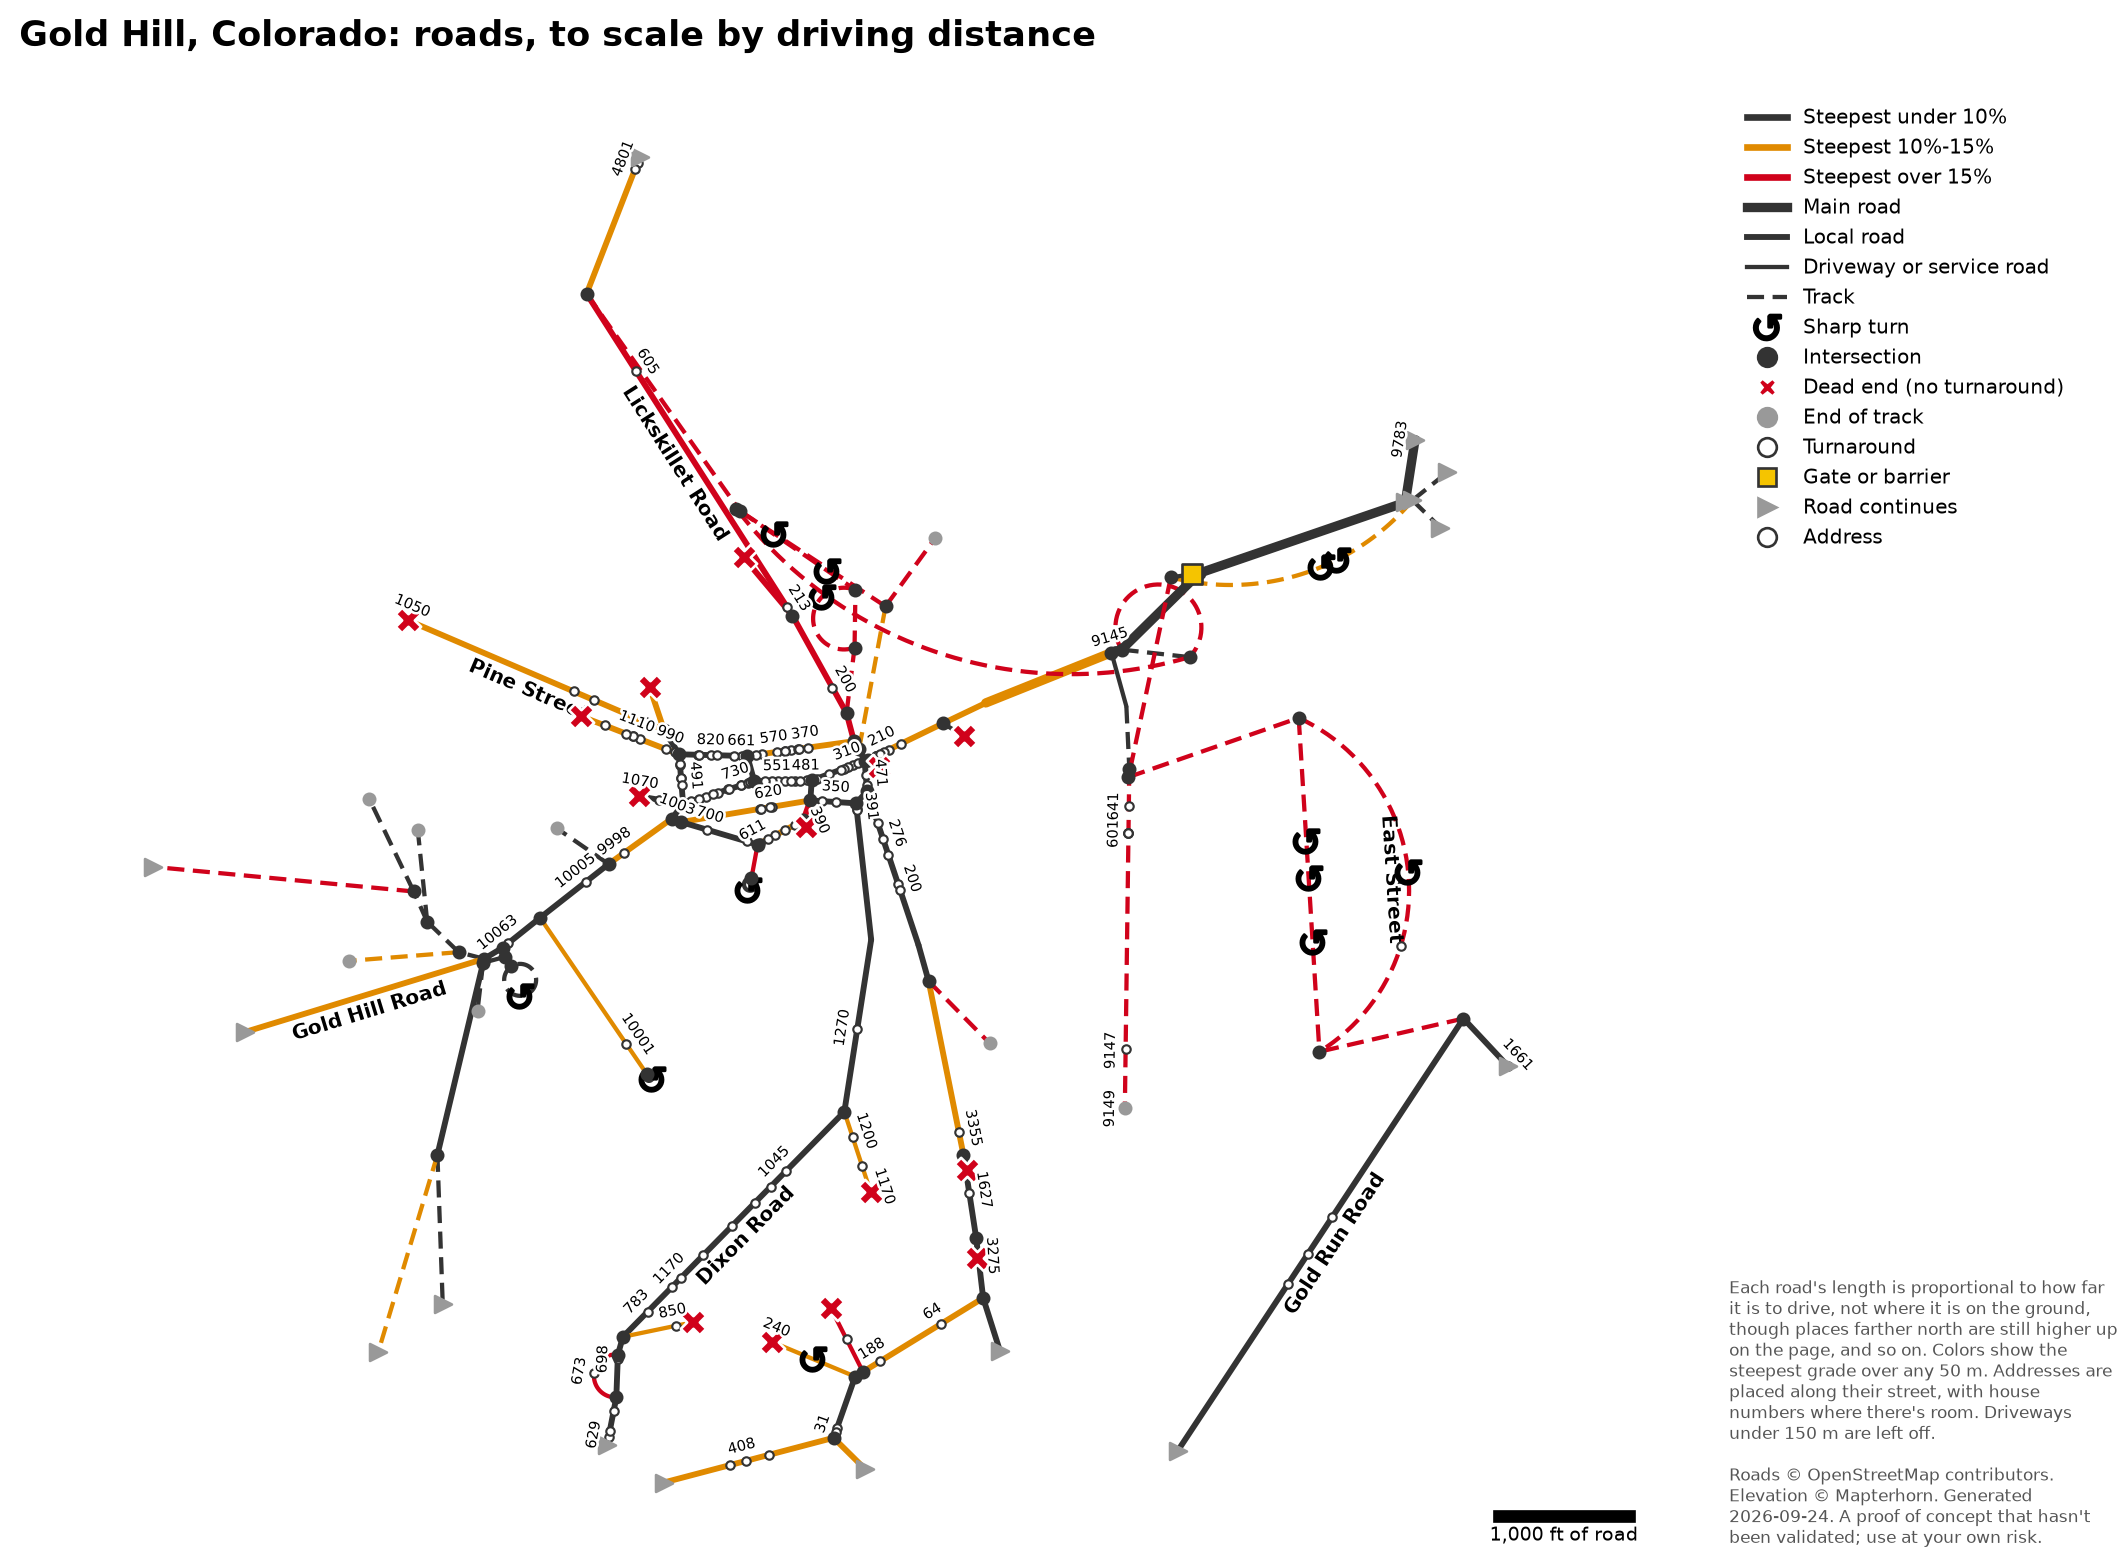

In [9]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from pyproj import Transformer
from shapely import Point

from ptps_wildfire_demo.road_graph.drawing import Diagram
from ptps_wildfire_demo.road_graph.links import firefighter_map_url, openstreetmap_url


def show_links(radius_meters):
    """Links to about the same area on regular maps, for comparison."""
    display(
        Markdown(
            f"The same area on the [firefighter map]({firefighter_map_url(CENTER, radius_meters)}) and [OpenStreetMap]({openstreetmap_url(CENTER, radius_meters)}). Click to enlarge."
        )
    )


to_projected = Transformer.from_crs("EPSG:4326", G.graph["crs"], always_xy=True)
CENTER_POINT = Point(*to_projected.transform(CENTER[1], CENTER[0]))

diagram = Diagram(
    G,
    result.pos,
    CENTER_POINT,
    RADIUS_METERS,
    grade_limits=(MAX_GRADE, STEEP_GRADE),
    note=(
        "Each road's length is proportional to how far it is to drive, not where it is on the ground, though places farther north are still higher up on the page, and so on. "
        f"Colors show the steepest grade over any {GRADE_SPAN_METERS} m. "
        "Addresses are placed along their street, with house numbers where there's room. "
        f"Driveways under {MIN_DRIVEWAY_METERS} m are left off.\n\n"
        f"Roads © OpenStreetMap contributors. Elevation © Mapterhorn. Generated {RUN_AT:%Y-%m-%d}. "
        "A proof of concept that hasn't been validated; use at your own risk."
    ),
)
show_links(RADIUS_METERS)
diagram.draw(f"{PLACE_NAME}: roads, to scale by driving distance")
plt.show()

At one scale, the town's short blocks get lost next to the long rural roads, so here's the middle of town on its own page, at a larger scale.


The same area on the [firefighter map](firefighter-map/#16.87/40.06300/-105.40900) and [OpenStreetMap](https://www.openstreetmap.org/#map=17/40.06300/-105.40900). Click to enlarge.

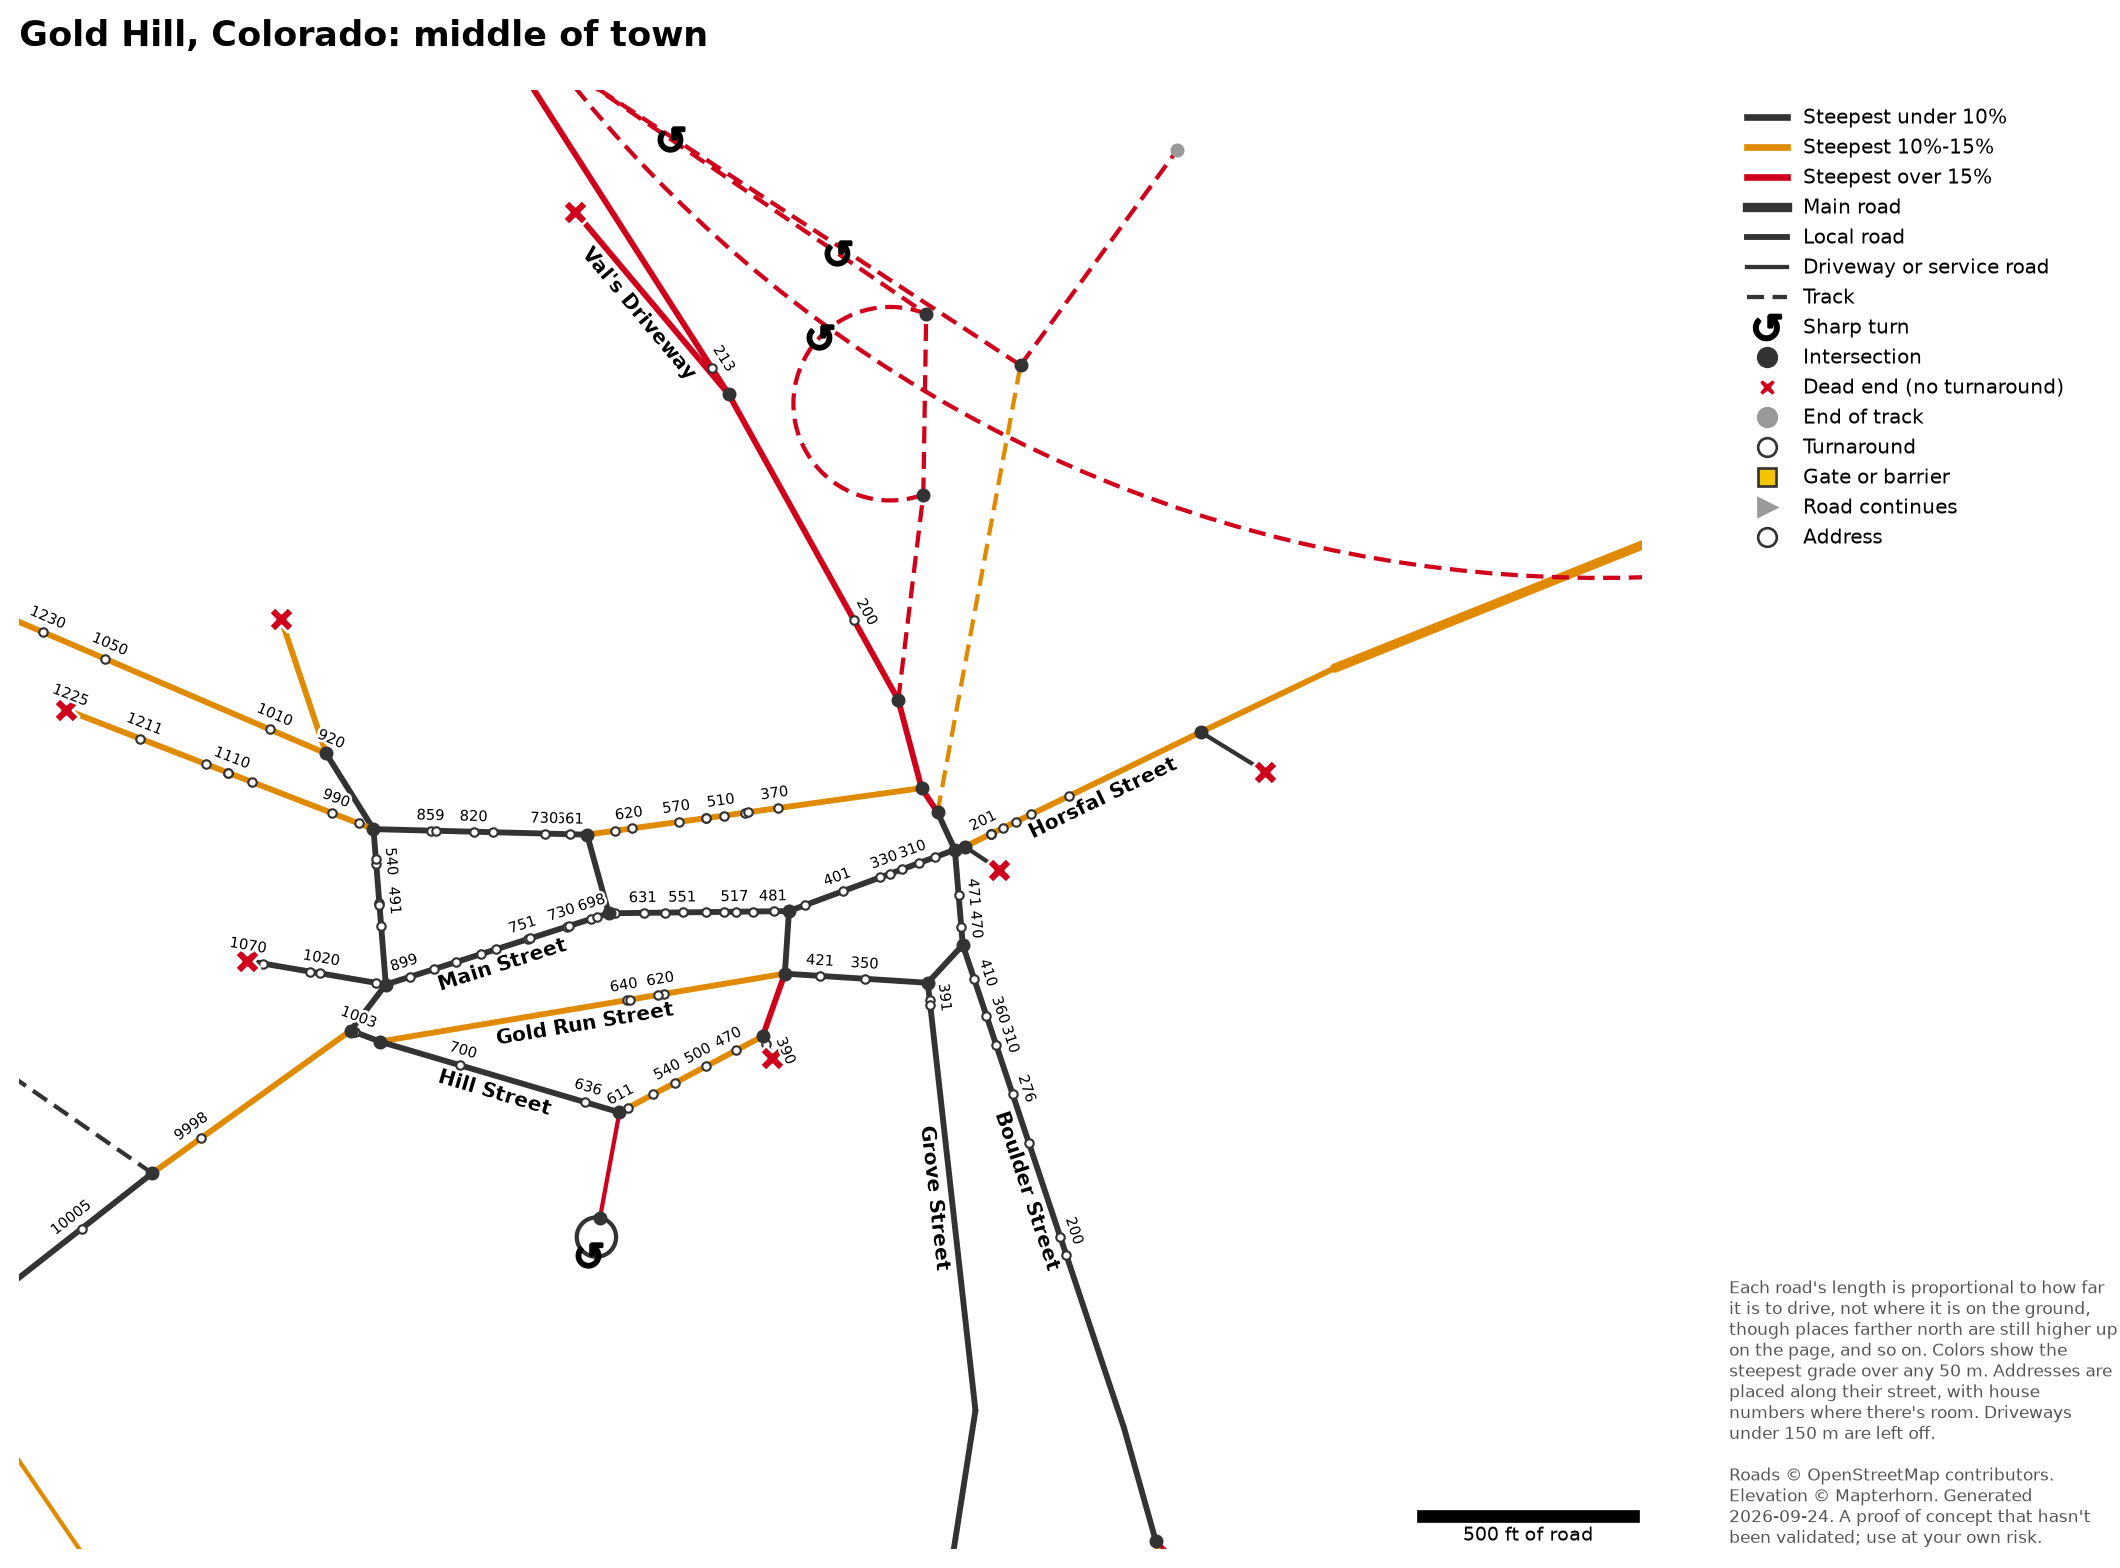

In [10]:
# the part of the diagram for intersections within this distance of CENTER on the ground
DETAIL_RADIUS_METERS = 400

near = np.array(
    [
        result.pos[n]
        for n, d in G.nodes(data=True)
        if CENTER_POINT.distance(Point(d["x"], d["y"])) <= DETAIL_RADIUS_METERS
    ]
)
(xmin, ymin), (xmax, ymax) = near.min(axis=0), near.max(axis=0)
margin = 0.1 * max(xmax - xmin, ymax - ymin)
show_links(DETAIL_RADIUS_METERS)
diagram.draw(
    f"{PLACE_NAME}: middle of town",
    (xmin - margin, ymin - margin, xmax + margin, ymax + margin),
)
plt.show()